In [4]:
import numpy as np

In [5]:
import sys
import torch
import matplotlib.pyplot as plt
import os
import xml.etree.ElementTree as ET
import cv2
import albumentations as A
import random

In [12]:
from collections import Counter
from sklearn.model_selection import train_test_split


In [16]:
import shutil

Для разметки данных использую labelimg.

In [ ]:
print(sys.executable)
print(sys.version)

/home/svetotch/ML_Itmo/machine_learning_hogweeds/venv/bin/python
3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]


In [6]:
print(torch.cuda.is_available())

True


In [7]:
images_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images"
labels_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels"

In [9]:
count = len(os.listdir(images_dir))
print(count)

5712


Всего боксов в train: 18002


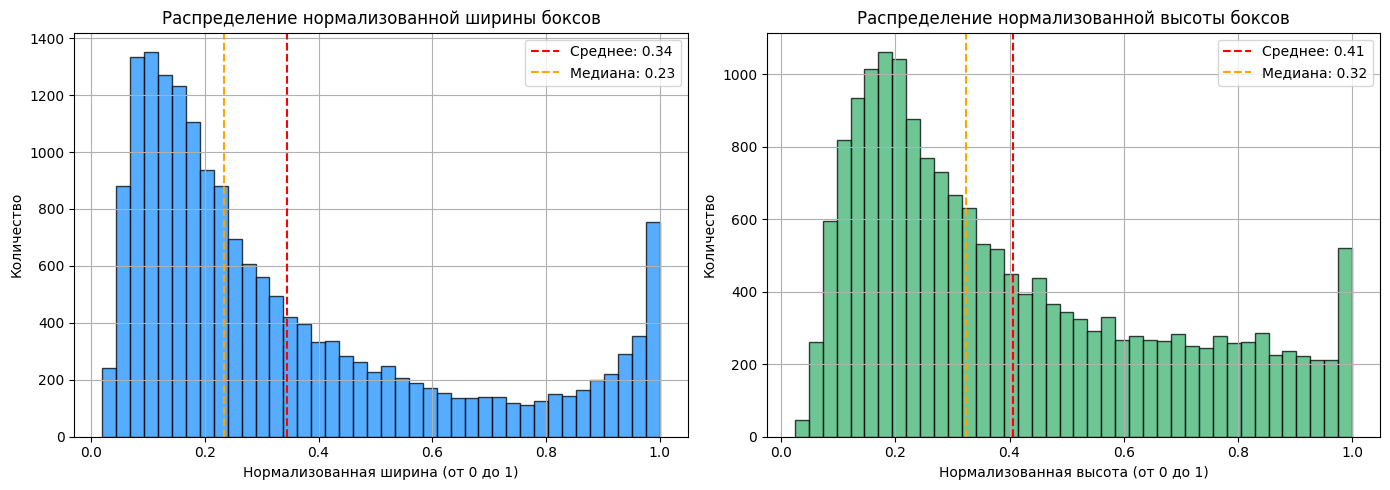

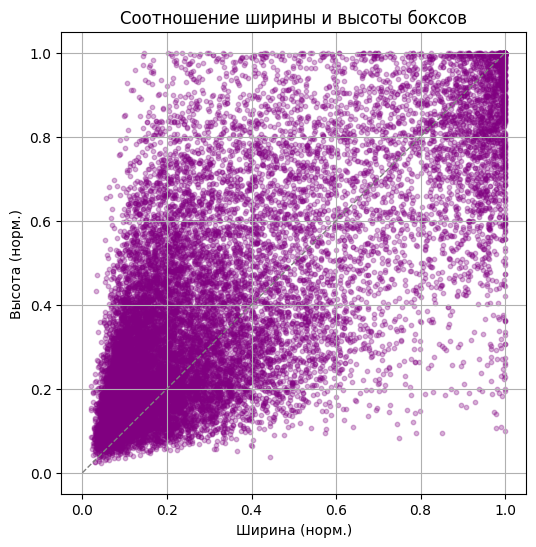

In [4]:
# списки для хранения ширины и высоты всех bounding boxes
widths = []
heights = []

# проходим по всем файлам разметки в train-части датасета
for filename in os.listdir(labels_dir):
    if not filename.endswith(".txt"):
        continue
    # полный путь к файлу разметки
    path = os.path.join(labels_dir, filename)
     # открываем файл
    with open(path, "r") as f:
        lines = f.readlines()
    # каждая строка = один объект (bounding box)
    for line in lines:
        # YOLO формат:
        # class x_center y_center width height
        cls, x_center, y_center, w, h = map(float, line.split())
        # сохраняем только размеры бокса (нас не интересует позиция)
        widths.append(w)
        heights.append(h)

print(f"Всего боксов в train: {len(widths)}")

# Преобразование в numpy для статистики
widths = np.array(widths)
heights = np.array(heights)

# Гистограммы 
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=40, color='dodgerblue', alpha=0.75, edgecolor='black')
plt.axvline(np.mean(widths), color='red', linestyle='--', label=f"Среднее: {np.mean(widths):.2f}")
plt.axvline(np.median(widths), color='orange', linestyle='--', label=f"Медиана: {np.median(widths):.2f}")
plt.title("Распределение нормализованной ширины боксов")
plt.xlabel("Нормализованная ширина (от 0 до 1)")
plt.ylabel("Количество")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(heights, bins=40, color='mediumseagreen', alpha=0.75, edgecolor='black')
plt.axvline(np.mean(heights), color='red', linestyle='--', label=f"Среднее: {np.mean(heights):.2f}")
plt.axvline(np.median(heights), color='orange', linestyle='--', label=f"Медиана: {np.median(heights):.2f}")
plt.title("Распределение нормализованной высоты боксов")
plt.xlabel("Нормализованная высота (от 0 до 1)")
plt.ylabel("Количество")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Точечный график 
plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.3, s=10, color='purple')
plt.title("Соотношение ширины и высоты боксов")
plt.xlabel("Ширина (норм.)")
plt.ylabel("Высота (норм.)")
plt.grid(True)

# Добавим линию x = y для ориентира
max_val = max(np.max(widths), np.max(heights))
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', linewidth=1)

plt.show()

{0: 4771, 1: 6766, 2: 6465}


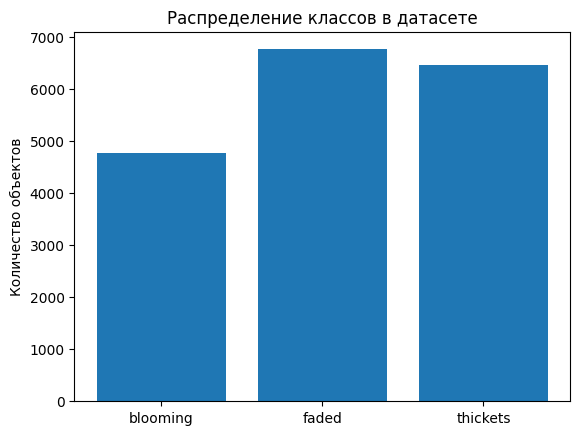

In [6]:
class_counts = {}

for file in os.listdir(labels_dir):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(labels_dir, file)

    with open(path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 0:
            continue

        cls_id = int(float(parts[0]))

        class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

print(class_counts)

names = ["blooming", "faded", "thickets"]
values = list(class_counts.values())

plt.figure()
plt.bar(names, values)
plt.title("Распределение классов в датасете")
plt.ylabel("Количество объектов")
plt.show()

In [1]:
# Куда сохранить новый датасет

output_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset_split"

In [8]:
# Создаем структуру YOLO

for split in ["train", "val", "test"]:
    os.makedirs(
        os.path.join(output_dir, "images", split),
        exist_ok=True
    )
    os.makedirs(
        os.path.join(output_dir, "labels", split),
        exist_ok=True
    )


# Получаем изображения

image_files = [
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]


print("Всего изображений:", len(image_files))


Всего изображений: 5712


In [9]:
# Функция получения классов изображения

def get_image_classes(label_file):

    classes = set()

    with open(label_file, "r") as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                classes.add(cls)

    return classes

In [10]:
# Создаем список изображений и их классов

data = []

for img in image_files:

    name = os.path.splitext(img)[0]

    label_path = os.path.join(
        labels_dir,
        name + ".txt"
    )

    if not os.path.exists(label_path):
        continue

    classes = get_image_classes(label_path)

    data.append(
        {
            "image": img,
            "classes": classes
        }
    )


print("Изображений с аннотациями:", len(data))

Изображений с аннотациями: 5712


In [11]:
# Для стратификации создаем метку
# если несколько классов на картинке,
# сортируем их в одну строку

stratify_labels = [
    "_".join(map(str, sorted(x["classes"])))
    for x in data
]


images = [
    x["image"]
    for x in data
]

In [13]:
# Сначала отделяем test 15%

train_val, test = train_test_split(
    images,
    test_size=0.15,
    random_state=42,
    stratify=stratify_labels
)


# Для train/val
train_val_labels = [
    "_".join(
        map(
            str,
            sorted(
                get_image_classes(
                    os.path.join(
                        labels_dir,
                        os.path.splitext(img)[0]+".txt"
                    )
                )
            )
        )
    )
    for img in train_val
]


In [14]:
# Делим train и val

train, val = train_test_split(
    train_val,
    test_size=0.1765,  
    random_state=42,
    stratify=train_val_labels
)


print()
print("TRAIN:", len(train))
print("VAL:", len(val))
print("TEST:", len(test))


TRAIN: 3998
VAL: 857
TEST: 857


In [18]:
# Копирование файлов

def copy_split(files, split):

    for img in files:

        name = os.path.splitext(img)[0]

        img_src = os.path.join(
            images_dir,
            img
        )

        lbl_src = os.path.join(
            labels_dir,
            name+".txt"
        )


        img_dst = os.path.join(
            output_dir,
            "images",
            split,
            img
        )

        lbl_dst = os.path.join(
            output_dir,
            "labels",
            split,
            name+".txt"
        )


        shutil.copy2(
            img_src,
            img_dst
        )

        shutil.copy2(
            lbl_src,
            lbl_dst
        )


copy_split(train, "train")
copy_split(val, "val")
copy_split(test, "test")


print("✅ Dataset split complete")


✅ Dataset split complete


In [19]:
classes_names = {
    0: "blooming_sosnovsky",
    1: "faded_sosnovsky",
    2: "thickets_sosnovsky"
}


def count_classes(label_dir):
    
    counter = Counter()

    label_files = [
        f for f in os.listdir(label_dir)
        if f.endswith(".txt")
    ]

    for file in label_files:

        path = os.path.join(label_dir, file)

        with open(path, "r") as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    counter[cls] += 1

    return counter



results = []



In [20]:
import pandas as pd

In [21]:
for split in ["train", "val", "test"]:

    label_path = os.path.join(
        output_dir,
        "labels",
        split
    )

    counts = count_classes(label_path)

    results.append(
        {
            "Split": split,
            "Images": len(os.listdir(
                os.path.join(
                    output_dir,
                    "images",
                    split
                )
            )),
            "blooming_sosnovsky": counts[0],
            "faded_sosnovsky": counts[1],
            "thickets_sosnovsky": counts[2],
            "Total objects": sum(counts.values())
        }
    )


df = pd.DataFrame(results)


print(df)


   Split  Images  blooming_sosnovsky  faded_sosnovsky  thickets_sosnovsky  \
0  train    3998                3343             4834                4513   
1    val     857                 694              951                 995   
2   test     857                 734              981                 957   

   Total objects  
0          12690  
1           2640  
2           2672  


In [22]:
# Добавим проценты внутри каждого split

for cls in classes_names.values():
    df[cls + " %"] = (
        df[cls] /
        df["Total objects"] * 100
    ).round(2)


df

,Split,Images,blooming_sosnovsky,faded_sosnovsky,thickets_sosnovsky,Total objects,blooming_sosnovsky %,faded_sosnovsky %,thickets_sosnovsky %
0,train,3998,3343,4834,4513,12690,26.34,38.09,35.56
1,val,857,694,951,995,2640,26.29,36.02,37.69
2,test,857,734,981,957,2672,27.47,36.71,35.82


## Анализ данных

Исходный датасет содержит 5712 изображений и 18002 объекта трёх классов. Для предотвращения изменения распределения классов при обучении была выполнена стратифицированная разбивка на обучающую, валидационную и тестовую выборки в соотношении 70/15/15.

После разделения доля каждого класса сохранилась приблизительно одинаковой во всех выборках: класс blooming_sosnovsky составляет около 26–27%, faded_sosnovsky — 36–38%, thickets_sosnovsky — 35–38%. Это позволяет избежать смещения модели в сторону наиболее представленного класса.

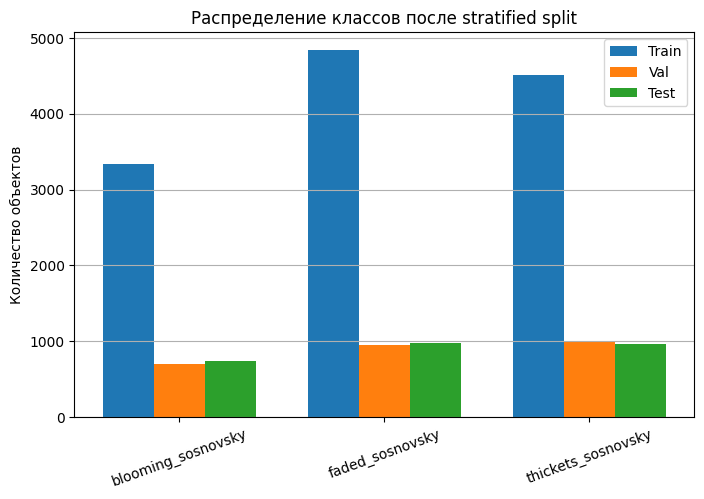

In [23]:
classes = [
    "blooming_sosnovsky",
    "faded_sosnovsky",
    "thickets_sosnovsky"
]

train_values = [
    3343,
    4834,
    4513
]

val_values = [
    694,
    951,
    995
]

test_values = [
    734,
    981,
    957
]


x = range(len(classes))

plt.figure(figsize=(8,5))

plt.bar(
    [i-0.25 for i in x],
    train_values,
    width=0.25,
    label="Train"
)

plt.bar(
    x,
    val_values,
    width=0.25,
    label="Val"
)

plt.bar(
    [i+0.25 for i in x],
    test_values,
    width=0.25,
    label="Test"
)


plt.xticks(
    x,
    classes,
    rotation=20
)

plt.ylabel("Количество объектов")
plt.title("Распределение классов после stratified split")

plt.legend()
plt.grid(axis="y")

plt.show()

In [24]:
from ultralytics import YOLO

## YOLO11n (baseline)

In [47]:
model = YOLO("yolo11n.pt")


model.train(
    data="dataset.yaml",

    epochs=100,
    imgsz=896,
    batch=6,

    # небольшая, аккуратная online-аугментация
    fliplr=0.5,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    copy_paste=0.2,

    # отключаем агрессивные методы
    mosaic=0.2,
    mixup=0.0,

    patience=20,

    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="hogweed_yolo11n_baseline"
)

New https://pypi.org/project/ultralytics/8.4.90 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0, name=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x75d68e650880>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

mixup не трогаем потомучто некоторые картинки и так неестественные

# Сильная аугментация данных не даёт прибавки. Пока аугментация:

 # небольшая, аккуратная online-аугментация
    fliplr=0.5, - Горизонтальное отражение

    hsv_h=0.015, - Небольшое изменение оттенка
    hsv_s=0.5, - Изменение насыщенности
    hsv_v=0.3, - Изменение яркости
# добавлены с 6 попытки
    degrees=5, - Небольшой поворот
    scale=0.1 - Небольшой сдвиг

# отключаем агрессивные методы
    mosaic=0.3, - Склейка 4 изображений
    mixup=0.0, - Смешивание изображений. Лучше оставить выключенным

    copy_paste=0.2 - вырезка и перестановка

Что я поняла: 
1) Борщевик — это растение с определённой геометрией:

вертикальные стебли;
листья;
фон земля/трава.

Даже небольшой поворот может ухудшить выделение признаков, особенно если объектов не очень много.

2) YOLO сама внутри делает resize до imgsz=896, поэтому дополнительный масштаб иногда приводит к тому, что маленькие объекты становятся слишком маленькими.

## Кличество картинок в датасете решает!!!!

In [48]:
model = YOLO(
    "/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline-7/weights/best.pt"
)


metrics = model.val(
    data="dataset.yaml",
    split="test",
    plots=True,

    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="yolo11n_test_eval"
)


print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10625.0±2942.2 MB/s, size: 1914.6 KB)
val: Scanning /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset_split/labels/test.cache... 857 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 857/857 326.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 13.0it/s 4.1s0.1s
                   all        857       2672      0.701      0.606      0.671      0.379
    blooming_sosnovsky        296        734      0.705      0.575      0.639       0.34
       faded_sosnovsky        339        981      0.779      0.727      0.791      0.467
    thickets_sosnovsky        418        957      0.618      0.514      0.582      0.331
Speed: 0.7ms preprocess, 1.4ms inference, 0.0ms l

## Лучшии показатели при:
data="dataset.yaml",

    epochs=100,
    imgsz=896,
    batch=6,

    # небольшая, аккуратная online-аугментация
    fliplr=0.5,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    copy_paste=0.2,

    # отключаем агрессивные методы
    mosaic=0.2,
    mixup=0.0,

    patience=20,

/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline-7

## Precision: 0.7006212463719765
## Recall: 0.6055114307174758
## mAP50: 0.6708714834650874
## mAP50-95: 0.37948854602918497

![val_batch2_pred](val_batch2_pred.jpg)

## При:
    imgsz=896,
    batch=4,

    # небольшая, аккуратная online-аугментация
    fliplr=0.5,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=5,
    scale=0.1,

    # отключаем агрессивные методы
    mosaic=0.2,

/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline-6

## Precision: 0.6734679907207158
## Recall: 0.5774845868190782
## mAP50: 0.6385868162604996
## mAP50-95: 0.34635186268216356

## При:
imgsz=896,
batch=4,
mosaic =0,2

/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline-5

## Precision: 0.707318909576204
## Recall: 0.5845174303775158
## mAP50: 0.6609107109187864
## mAP50-95: 0.3705025960903223

## При:
imgsz=768,
batch=4,
mosaic =0,2

/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline-4

## Precision: 0.6787162521034942
## Recall: 0.5941682702613019
## mAP50: 0.653591437579715
## mAP50-95: 0.3697812505900784

## При:
imgsz=640,
batch=4

/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline-2

## Precision: 0.657038403822421
## Recall: 0.5586597441002545
## mAP50: 0.6241610171209512
## mAP50-95: 0.35413299940782417


## При:
imgsz=768,
batch=4

/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline

## Precision: 0.6655658235064276
## Recall: 0.5586597441002545
## mAP50: 0.6393932962450461
## mAP50-95: 0.3575042571455891

## При:
imgsz=768,
batch=4,
mosaic=0.3

/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11n_baseline-3


## Precision: 0.6521059457984586
## Recall: 0.6022725414361232
## mAP50: 0.6489623926415807
## mAP50-95: 0.36940467553819273


Модель достаточно хорошо обнаруживает объекты, однако значение Recall ниже Precision, что говорит о наличии значительного количества пропущенных объектов (false negative). 
Наиболее вероятные ошибки связаны с обнаружением менее выраженных стадий развития борщевика, где визуальные признаки классов могут быть менее заметными.

## YOLO11s (для разметки)

In [ ]:
model = YOLO("yolo11s.pt")

model.train(
    data="dataset.yaml",

    epochs=100,
    imgsz=896,
    batch=4,

    # небольшая, аккуратная online-аугментация
    fliplr=0.5,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=5,
    scale=0.1,

    # отключаем агрессивные методы
    mosaic=0.3,
    mixup=0.0,

    patience=20,

    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="hogweed_yolo11s_baseline"
)


Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hogweed_yolo11s_thickets, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d10c11a7400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

model = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_yolo11s_thickets/weights/best.pt")

model.predict(
    source="/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/thickets/thickest_test",
    conf=0.2,
    save=True,
    save_txt=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="thickets_data"
)

In [ ]:
metrics = model.val(
    data="dataset.yaml",
    split="test",
    plots=True,

    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="yolo11n_test_eval"
)


print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

## YOLOn

In [3]:
model = YOLO("yolov8n.pt")

model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="/home/svetotch/ML_Itmo/yolo_runs", 
    name="hogweed_exp1"
)

New https://pypi.org/project/ultralytics/8.4.75 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15832MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7788cad84e50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
model = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_exp1/weights/best.pt")

In [13]:
print(len(os.listdir("/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test")))

301


In [14]:
metrics = model.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="val_exp1"
)

print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)
print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7622.7±6778.3 MB/s, size: 1408.4 KB)
val: Scanning /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 3.9Kit/s 0.1s
val: New cache created: /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 13.3it/s 1.4s0.1s
                   all        301        834      0.401      0.386      0.338      0.167
    blooming_sosnovsky        291        665      0.653      0.644      0.697      0.368
       faded_sosnovsky         34         58      0.269      0.172       0.12     0.0486
    thickets_sosnovsky         57        111

Сейчас сильный дисбаланс так как модель обученна только на части датасета где есть цветущий борщевик

так как датасет пока размечен не до конца, модель йоло пока плохо находит классы 2 и 1

Однако она очень хорошо находит класс blooming.


Первая модель просто обученная YOLOv8 Nano. Результаты метрик:
# Precision = 0.401498988959478
# Recall = 0.38612171933406053
# mAP50 = 0.3383189593039473
# mAP50-95 = 0.16677254396548885

In [ ]:
results = model.predict(
    source="/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test",
    conf=0.23,
    save=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="predict_exp1"
)

Ещё одна модель. На этот раз yolov8small

In [ ]:
model2 = YOLO("yolov8s.pt")

model2.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="/home/svetotch/ML_Itmo/yolo_runs", 
    name="hogweed_exp2"
)

New https://pypi.org/project/ultralytics/8.4.69 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7685b6a202e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
model2 = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_exp2/weights/best.pt")
metrics = model2.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="test_exp2"
)

print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)
print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14396.5±3183.4 MB/s, size: 1736.9 KB)
val: Scanning /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test.cache... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 90.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 9.9it/s 1.9s<0.1s
                   all        301        834      0.471      0.411      0.397      0.196
    blooming_sosnovsky        291        665      0.707       0.65       0.72      0.387
       faded_sosnovsky         34         58      0.407      0.276      0.204      0.083
    thickets_sosnovsky         57        111      0.299      0.306      0.268      0.118
Speed: 0.6ms preprocess, 2.8ms inference, 0.0ms loss, 0.9

In [ ]:
results = model2.predict(
    source="/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test",
    conf=0.23,
    save=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="predict_exp2"
)


image 1/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0004.jpg: 480x640 1 blooming_sosnovsky, 18.2ms
image 2/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0008.jpg: 640x640 1 blooming_sosnovsky, 3.8ms
image 3/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0010.jpg: 640x480 1 blooming_sosnovsky, 17.4ms
image 4/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0016.jpg: 640x480 1 blooming_sosnovsky, 2.5ms
image 5/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0018.jpg: 480x640 5 blooming_sosnovskys, 3 thickets_sosnovskys, 2.5ms
image 6/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0033.jpg: 640x480 3 blooming_sosnovskys, 2 thickets_sosnovskys, 2.6ms
image 7/301 /home/svetotch/ML_Itmo/machine_learning_hog

# Precision = 0.4707891633767655
# Recall = 0.4105974784740665
# mAP50 = 0.3972891420088777
# mAP50-95 = 0.19620398533894992

Для сравнения были обучены две модели: YOLOv8n и YOLOv8s. 

Вторая модель показала лучшие результаты по всем метрикам качества. 
Наибольший прирост наблюдался по Precision и mAP@0.5, что свидетельствует о более точной локализации объектов и меньшем количестве ложных срабатываний. 
Совокупная метрика качества mAP@0.5:0.95 увеличилась с 0.167 до 0.196, что соответствует приросту около 17%.

In [6]:
train_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/train"
val_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/val"
test_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test"


train_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/train"
val_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/val"
test_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test"

## Аугментация

In [ ]:
# Сколько копий делать
N_AUG = 3

transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20,
            p=0.5
        ),

        A.Rotate(
            limit=15,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5
        ),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

In [29]:
def read_yolo_label(path):
    boxes = []
    labels = []

    with open(path, "r") as f:
        for line in f:
            cls, x, y, w, h = map(float, line.strip().split())

            labels.append(int(cls))
            boxes.append([x, y, w, h])

    return boxes, labels

In [30]:
def save_yolo_label(path, boxes, labels):
    with open(path, "w") as f:
        for cls, box in zip(labels, boxes):
            x, y, w, h = box
            f.write(f"{cls} {x} {y} {w} {h}\n")

In [31]:
for image_name in os.listdir(train_bloom_images):

    if not image_name.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):
        continue

    image_path = os.path.join(train_bloom_images, image_name)

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(train_bloom_labels, label_name)

    if not os.path.exists(label_path):
        continue

    boxes, labels = read_yolo_label(label_path)

    # аугментируем только редкие классы
    if not any(cls in [1, 2] for cls in labels):
        continue

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for i in range(N_AUG):

        transformed = transform(
            image=image,
            bboxes=boxes,
            class_labels=labels
        )

        aug_image = transformed["image"]
        aug_boxes = transformed["bboxes"]
        aug_labels = transformed["class_labels"]

        new_image_name = (
            os.path.splitext(image_name)[0]
            + f"_aug_{i}.jpg"
        )

        new_label_name = (
            os.path.splitext(image_name)[0]
            + f"_aug_{i}.txt"
        )

        cv2.imwrite(
            os.path.join(train_bloom_images, new_image_name),
            cv2.cvtColor(
                aug_image,
                cv2.COLOR_RGB2BGR
            )
        )

        save_yolo_label(
            os.path.join(train_bloom_labels, new_label_name),
            aug_boxes,
            aug_labels
        )

print("Аугментация завершена.")

Аугментация завершена.


{0: 7379, 1: 1100, 2: 2740}


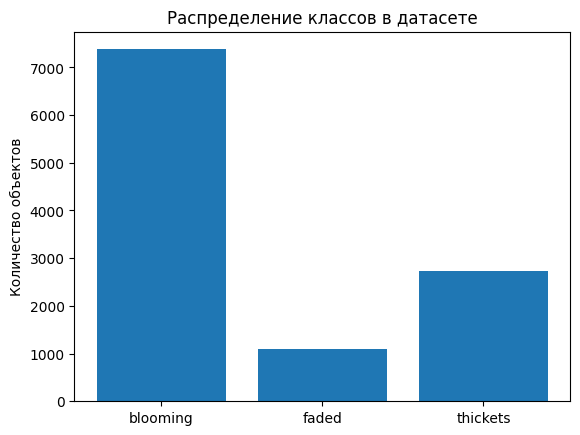

In [6]:
labels_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/train"

class_counts = {}

for file in os.listdir(labels_dir):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(labels_dir, file)

    with open(path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 0:
            continue

        cls_id = int(float(parts[0]))

        class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

print(class_counts)

names = ["blooming", "faded", "thickets"]
values = list(class_counts.values())

plt.figure()
plt.bar(names, values)
plt.title("Распределение классов в датасете")
plt.ylabel("Количество объектов")
plt.show()

Аугментация на данный момент не увеличит точность так как датасет не полностью пока помечен

Модель с аугментацией

In [32]:
model2 = YOLO("yolov8s.pt")

model2.train(
    data="dataset.yaml",
    epochs=80,
    imgsz=960,
    mosaic=1.0,
    mixup=0.2,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    batch=8,
    project="/home/svetotch/ML_Itmo/yolo_runs", 
    name="hogweed_exp3"
)

New https://pypi.org/project/ultralytics/8.4.76 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15832MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7785a4a7a800>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [33]:
model2 = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_exp3-3/weights/best.pt")
metrics = model2.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="test_exp3-3"
)

print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)
print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15832MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1419.9±360.2 MB/s, size: 1736.9 KB)
val: Scanning /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 3.9Kit/s 0.1s
val: New cache created: /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 6.1it/s 3.1s<0.2s
                   all        301        834      0.447      0.376      0.328       0.14
    blooming_sosnovsky        291        665      0.638      0.626      0.624      0.274
       faded_sosnovsky         34         58      0.389      0.259      0.169     0.0713
    thickets_sosnovsky         57        11

Модель с аугментированным датасетом показала результат хуже.

## Precision = 0.44745841750851617 
## Recall = 0.37580928089095056 
## mAP50 = 0.3276943831072961 
## mAP50-95 = 0.1403370683995934

Посравнению с предыдущей 

# Precision = 0.4707891633767655
# Recall = 0.4105974784740665
# mAP50 = 0.3972891420088777
# mAP50-95 = 0.19620398533894992

Делаю вывод что аугментация на данный момент не даёт результат. Так как yolo уже сама по себе хорошо обучена(скорее нет, чем да). Аугментация скорее больше шум на данный момент.

То, что среднее больше медианы, говорит о правосторонней асимметрии распределения. Иными словами:

большинство объектов имеют небольшие или средние размеры;
присутствует заметное количество очень крупных объектов, которые смещают среднее значение вправо.

Это типичная ситуация для задач детекции растений:

часть изображений содержит отдельные растения крупным планом;
часть — группы растений или растения на большом расстоянии.


На обеих гистограммах хорошо заметен пик около значения 1.0.

Это означает, что в датасете присутствует значительное число боксов, занимающих практически всё изображение.

Это повышает разнообразие масштабов объектов и способствует более устойчивому обучению модели? 

Из графиков видно, что ширина и высота объектов изменяются практически по всему диапазону

Это очень хороший признак для YOLO.




Положительная корреляция:

Чем шире объект, тем выше он становится.

Точки образуют диагональное облако.

Это говорит о том, что большинство объектов сохраняют примерно одинаковые пропорции.

Анализ 4262 размеченных объектов показал высокую вариативность размеров bounding boxes. Большинство объектов имеют небольшие и средние размеры, однако в выборке также присутствует значительное количество крупных объектов, занимающих большую часть изображения. Наблюдается положительная корреляция между шириной и высотой объектов, что свидетельствует о согласованности разметки и отсутствии значительного числа аномальных ограничивающих прямоугольников.

Пробую добавить backbone

Пример найденного борщевика из тестовой выборки

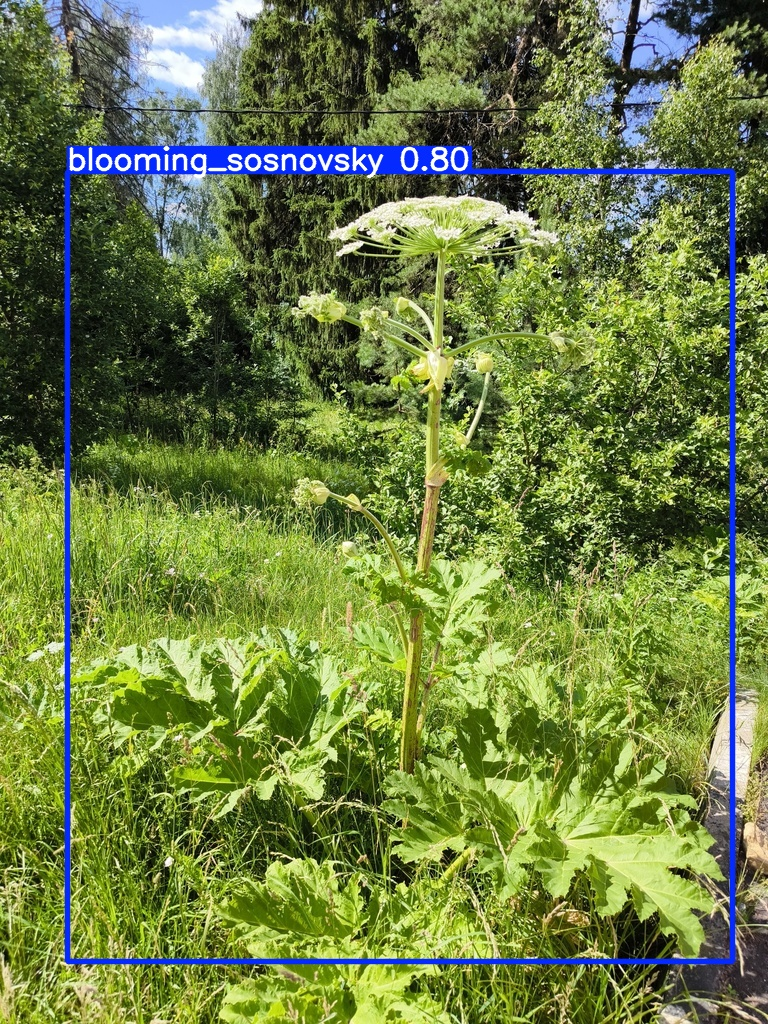

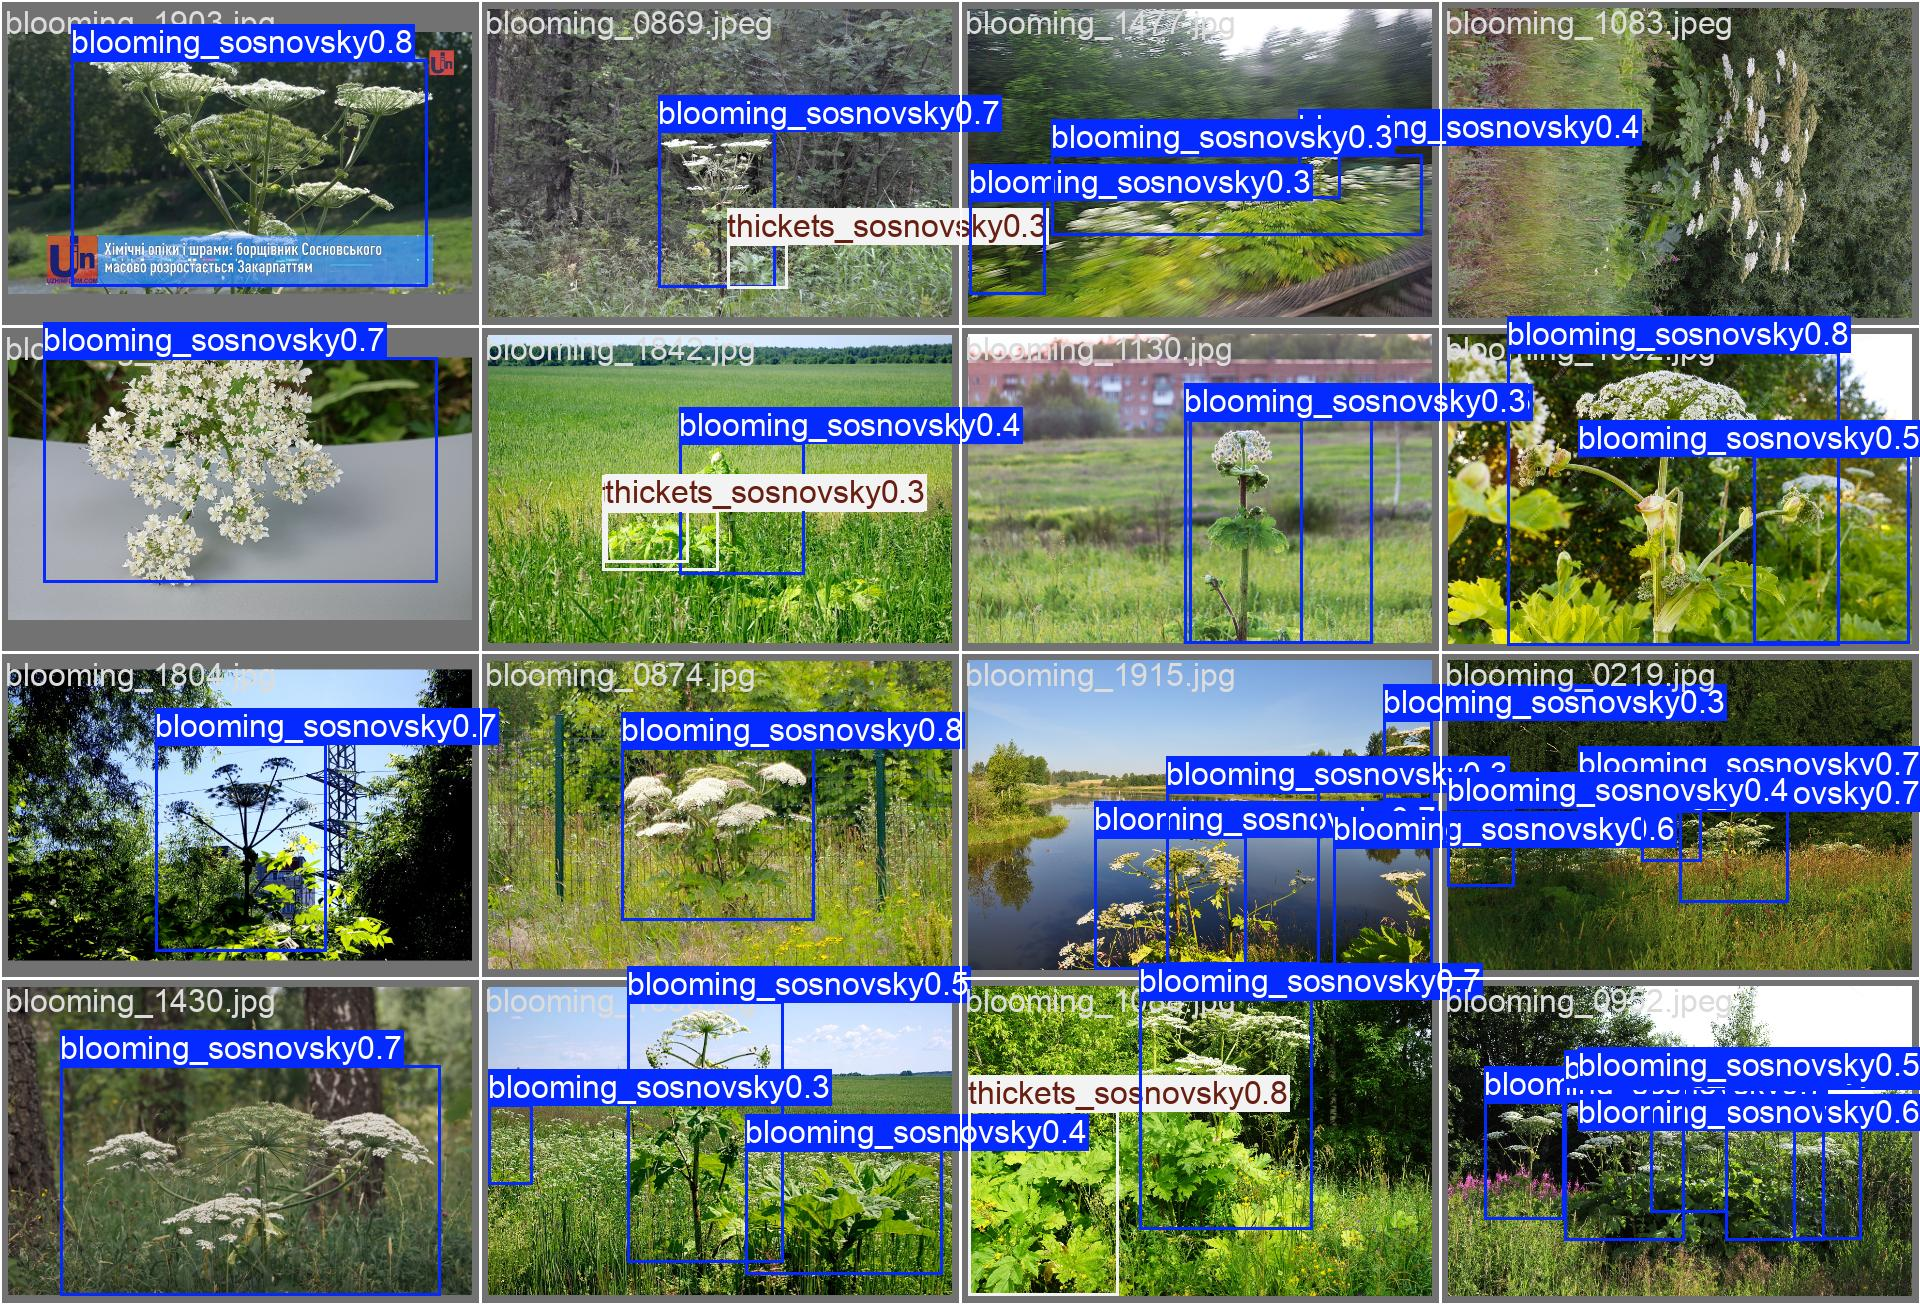